<a href="https://colab.research.google.com/github/Matheesha-w/SE4050-Lab8/blob/main/DQN_Gridworld.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Deep Q-Learning (DQN) - GridWorld

Same GridWorld as before, but the Q-table is replaced with a neural network. The state (agent position) is given as a one-hot vector and the network outputs a Q-value for each action. A replay buffer and a target network are used. The agent is trained with epsilon = 0.1, 0.5 and 0.9.

In [ ]:
import time, random
from collections import deque
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import torch
import torch.nn as nn
import torch.optim as optim
%matplotlib inline

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print('Using device:', device)

def set_seed(seed):
    random.seed(seed); np.random.seed(seed); torch.manual_seed(seed)

Using device: cpu


## Environment

In [ ]:
class GridWorld:
    def __init__(self, height=8, width=8):
        self.height = height
        self.width = width
        self.grid = np.zeros((self.height, self.width)) - 1
        self.current_location = (self.height // 2, np.random.randint(0, min(5, self.width)))
        self.bomb_location = (1, self.width // 2 - 1)
        self.gold_location = (0, self.width // 2 - 1)
        self.terminal_states = [self.bomb_location, self.gold_location]
        self.grid[self.bomb_location] = -10
        self.grid[self.gold_location] = 10
        self.actions = ['UP', 'DOWN', 'LEFT', 'RIGHT']

    def reset(self):
        self.__init__(self.height, self.width)
        return self.current_location

    def get_reward(self, new_location):
        return self.grid[new_location[0], new_location[1]]

    def make_step(self, action):
        r, c = self.current_location
        if action == 'UP':      r = max(r - 1, 0)
        elif action == 'DOWN':  r = min(r + 1, self.height - 1)
        elif action == 'LEFT':  c = max(c - 1, 0)
        elif action == 'RIGHT': c = min(c + 1, self.width - 1)
        self.current_location = (r, c)
        return self.get_reward(self.current_location)

    def check_state(self):
        if self.current_location in self.terminal_states:
            return 'TERMINAL'

    # one-hot state vector for the network
    def encode(self, location):
        v = np.zeros(self.height * self.width, dtype=np.float32)
        v[location[0] * self.width + location[1]] = 1.0
        return v

## DQN Agent

In [ ]:
class QNetwork(nn.Module):
    def __init__(self, n_inputs, n_actions, hidden=128):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(n_inputs, hidden), nn.ReLU(),
            nn.Linear(hidden, hidden), nn.ReLU(),
            nn.Linear(hidden, n_actions))

    def forward(self, x):
        return self.net(x)


class ReplayBuffer:
    def __init__(self, capacity=10000):
        self.buffer = deque(maxlen=capacity)

    def push(self, s, a, r, s_next, done):
        self.buffer.append((s, a, r, s_next, done))

    def sample(self, batch_size):
        batch = random.sample(self.buffer, batch_size)
        s, a, r, s_next, done = map(np.array, zip(*batch))
        return (torch.tensor(s, dtype=torch.float32, device=device),
                torch.tensor(a, dtype=torch.int64, device=device),
                torch.tensor(r, dtype=torch.float32, device=device),
                torch.tensor(s_next, dtype=torch.float32, device=device),
                torch.tensor(done, dtype=torch.float32, device=device))

    def __len__(self):
        return len(self.buffer)


class DQN_Agent:
    def __init__(self, environment, epsilon=0.1, gamma=0.99, lr=1e-3, batch_size=64,
                 buffer_size=10000, target_update=200, hidden=128):
        self.environment = environment
        self.n_states = environment.height * environment.width
        self.n_actions = len(environment.actions)
        self.epsilon = epsilon
        self.gamma = gamma
        self.batch_size = batch_size
        self.target_update = target_update
        self.q_net = QNetwork(self.n_states, self.n_actions, hidden).to(device)
        self.target_net = QNetwork(self.n_states, self.n_actions, hidden).to(device)
        self.target_net.load_state_dict(self.q_net.state_dict())
        self.target_net.eval()
        self.optimizer = optim.Adam(self.q_net.parameters(), lr=lr)
        self.memory = ReplayBuffer(buffer_size)
        self.learn_steps = 0

    def q_values(self, state_vec):
        with torch.no_grad():
            return self.q_net(torch.tensor(state_vec, device=device).unsqueeze(0)).squeeze(0).cpu().numpy()

    def choose_action(self, state_vec, epsilon=None):
        # epsilon-greedy
        eps = self.epsilon if epsilon is None else epsilon
        if np.random.uniform(0, 1) < eps:
            return np.random.randint(self.n_actions)
        q = self.q_values(state_vec)
        return int(np.random.choice(np.flatnonzero(q == q.max())))

    def learn(self):
        if len(self.memory) < self.batch_size:
            return None
        s, a, r, s_next, done = self.memory.sample(self.batch_size)
        q_sa = self.q_net(s).gather(1, a.unsqueeze(1)).squeeze(1)
        with torch.no_grad():
            max_q_next = self.target_net(s_next).max(dim=1)[0]
            target = r + self.gamma * max_q_next * (1 - done)
        loss = nn.functional.smooth_l1_loss(q_sa, target)
        self.optimizer.zero_grad()
        loss.backward()
        self.optimizer.step()
        self.learn_steps += 1
        if self.learn_steps % self.target_update == 0:
            self.target_net.load_state_dict(self.q_net.state_dict())
        return loss.item()

## Training

Training reward is recorded every episode. Every 10 episodes the greedy policy (epsilon = 0) is also tested from each start position.

In [ ]:
def evaluate_greedy(env, agent, max_steps=100):
    total, success, starts = 0.0, 0, list(range(min(5, env.width)))
    for c in starts:
        env.reset()
        env.current_location = (env.height // 2, c)
        ep_reward = 0
        for t in range(max_steps):
            a = agent.choose_action(env.encode(env.current_location), epsilon=0.0)
            ep_reward += env.make_step(env.actions[a])
            if env.check_state() == 'TERMINAL':
                success += int(env.current_location == env.gold_location)
                break
        total += ep_reward
    env.reset()
    return total / len(starts), success / len(starts)


def train_dqn(epsilon, episodes=300, max_steps=200, seed=0, eval_every=10):
    set_seed(seed)
    env = GridWorld()
    agent = DQN_Agent(env, epsilon=epsilon)
    log = {'reward': [], 'steps': [], 'loss': [], 'eval_ep': [], 'eval_reward': [], 'eval_success': []}
    t0 = time.perf_counter()
    for ep in range(episodes):
        env.reset()
        s = env.encode(env.current_location)
        ep_reward, ep_losses = 0, []
        for step in range(max_steps):
            a = agent.choose_action(s)
            r = env.make_step(env.actions[a])
            done = env.check_state() == 'TERMINAL'
            s_next = env.encode(env.current_location)
            agent.memory.push(s, a, r, s_next, float(done))
            loss = agent.learn()
            if loss is not None:
                ep_losses.append(loss)
            ep_reward += r
            s = s_next
            if done:
                break
        log['reward'].append(ep_reward)
        log['steps'].append(step + 1)
        log['loss'].append(np.mean(ep_losses) if ep_losses else np.nan)
        if (ep + 1) % eval_every == 0:
            er, es = evaluate_greedy(GridWorld(), agent)
            log['eval_ep'].append(ep + 1); log['eval_reward'].append(er); log['eval_success'].append(es)
    log['time'] = time.perf_counter() - t0
    return agent, log

## Different epsilon values

In [ ]:
epsilons = [0.1, 0.5, 0.9]
EPISODES = 300
agents, logs = {}, {}
for eps in epsilons:
    agents[eps], logs[eps] = train_dqn(eps, episodes=EPISODES)
    print('epsilon={}: time {:.1f}s, final greedy reward {:.2f}, success rate {:.0%}'.format(
        eps, logs[eps]['time'], logs[eps]['eval_reward'][-1], logs[eps]['eval_success'][-1]))

epsilon=0.1: time 11.5s, final greedy reward 5.20, success rate 100%
epsilon=0.5: time 13.5s, final greedy reward 5.20, success rate 100%
epsilon=0.9: time 30.3s, final greedy reward 5.20, success rate 100%


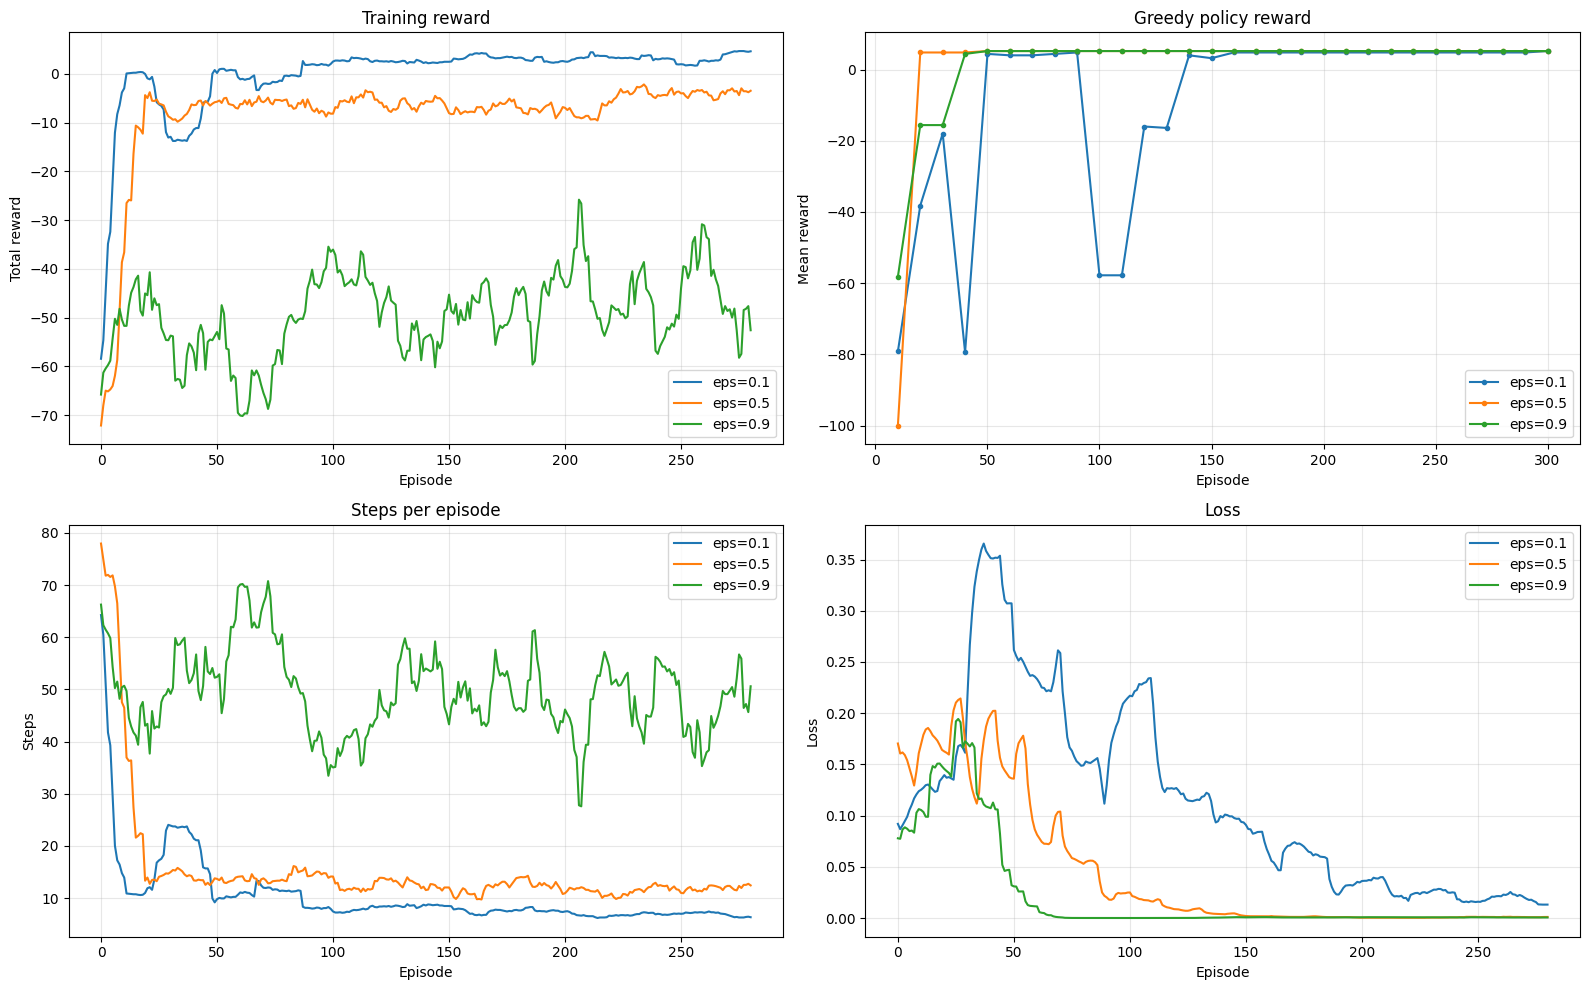

,epsilon,Training reward (last 50),Steps/episode (last 50),Greedy reward,Success rate,Converged at episode,Time (s)
0,0.1,3.36,6.8,5.2,100%,160,11.5
1,0.5,-3.86,12.1,5.2,100%,20,13.5
2,0.9,-48.06,49.0,5.2,100%,40,30.3


In [ ]:
def moving_average(x, w=20):
    x = np.asarray(x, dtype=float)
    return np.convolve(x, np.ones(w) / w, mode='valid')

def convergence_episode(log, tol=1.0):
    er = np.array(log['eval_reward']); final = er[-1]
    for i in range(len(er)):
        if np.all(np.abs(er[i:] - final) <= tol):
            return log['eval_ep'][i]
    return log['eval_ep'][-1]

colors = {0.1: 'tab:blue', 0.5: 'tab:orange', 0.9: 'tab:green'}
fig, axs = plt.subplots(2, 2, figsize=(16, 10))
for eps in epsilons:
    L = logs[eps]
    axs[0, 0].plot(moving_average(L['reward']), color=colors[eps], label='eps={}'.format(eps))
    axs[0, 1].plot(L['eval_ep'], L['eval_reward'], 'o-', ms=3, color=colors[eps], label='eps={}'.format(eps))
    axs[1, 0].plot(moving_average(L['steps']), color=colors[eps], label='eps={}'.format(eps))
    axs[1, 1].plot(moving_average(np.nan_to_num(L['loss'])), color=colors[eps], label='eps={}'.format(eps))
axs[0, 0].set_title('Training reward'); axs[0, 0].set_xlabel('Episode'); axs[0, 0].set_ylabel('Total reward')
axs[0, 1].set_title('Greedy policy reward'); axs[0, 1].set_xlabel('Episode'); axs[0, 1].set_ylabel('Mean reward')
axs[1, 0].set_title('Steps per episode'); axs[1, 0].set_xlabel('Episode'); axs[1, 0].set_ylabel('Steps')
axs[1, 1].set_title('Loss'); axs[1, 1].set_xlabel('Episode'); axs[1, 1].set_ylabel('Loss')
for ax in axs.flat:
    ax.legend(); ax.grid(alpha=0.3)
plt.tight_layout(); plt.show()

summary = pd.DataFrame([{
    'epsilon': eps,
    'Training reward (last 50)': round(np.mean(logs[eps]['reward'][-50:]), 2),
    'Steps/episode (last 50)': round(np.mean(logs[eps]['steps'][-50:]), 1),
    'Greedy reward': round(logs[eps]['eval_reward'][-1], 2),
    'Success rate': '{:.0%}'.format(logs[eps]['eval_success'][-1]),
    'Converged at episode': convergence_episode(logs[eps]),
    'Time (s)': round(logs[eps]['time'], 1)} for eps in epsilons])
display(summary)

## Learned policy

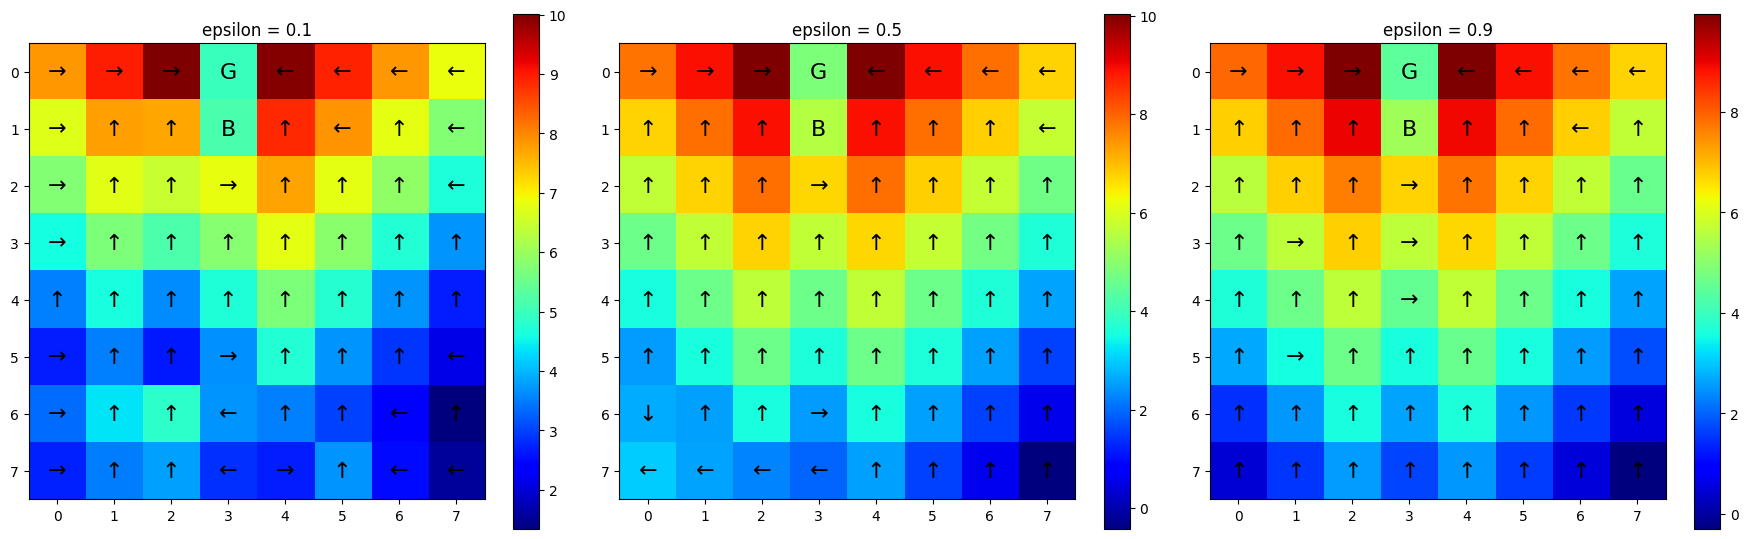

In [ ]:
arrow = {0: '\u2191', 1: '\u2193', 2: '\u2190', 3: '\u2192'}
fig, axs = plt.subplots(1, 3, figsize=(18, 5.5))
for ax, eps in zip(axs, epsilons):
    env = GridWorld()
    V = np.zeros((env.height, env.width))
    for r in range(env.height):
        for c in range(env.width):
            q = agents[eps].q_values(env.encode((r, c)))
            V[r, c] = q.max()
            if (r, c) == env.gold_location:   label = 'G'
            elif (r, c) == env.bomb_location: label = 'B'
            else:                             label = arrow[int(q.argmax())]
            ax.text(c, r, label, ha='center', va='center', fontsize=16, color='k')
    im = ax.imshow(V, cmap='jet')
    plt.colorbar(im, ax=ax)
    ax.set_title('epsilon = {}'.format(eps))
    ax.set_xticks(range(env.width)); ax.set_yticks(range(env.height))
plt.tight_layout(); plt.show()

## Observations

All three epsilon values ended with the same greedy reward of 5.2 and a 100% success rate. 5.2 is the best possible average from the five start positions, so in all cases the network learned the optimal path to the gold.

With epsilon = 0.1 the training reward was the highest (about 3.4 in the last 50 episodes, with around 7 steps per episode) because the agent mostly follows the best action. But the greedy policy was unstable at the start. It dropped back to around -58 at episodes 100 to 110 and only became stable around episode 160. The loss was also higher and noisier. In the policy map some cells that are rarely visited (bottom rows) still have wrong arrows, because the agent did not explore them much.

With epsilon = 0.5 the greedy policy reached the best reward very early (around episode 20). The training reward was lower (about -3.9) since half of the actions are random.

With epsilon = 0.9 the training reward stayed very low (about -48) with around 49 steps per episode, because the agent acts almost randomly. Training also took the longest (30s compared to 11.5s). Still, the greedy policy converged early (episode 40) and the policy map is the cleanest, with sensible arrows in almost every cell. This is because DQN learns off-policy from the replay buffer, so the random data still covers the whole grid.

So a small epsilon gives better rewards while training, but explores less and learns the less visited states poorly. A large epsilon explores well but wastes a lot of steps. Starting with a high epsilon and decreasing it over time would combine both.

Compared to the Q-table, DQN is slower on this small grid, but the network can handle much larger state spaces where a table would not be practical.